In [5]:
from numba import njit, set_num_threads
import ll_checker_numba as lcn
import LLcython_pra as llp
import ll_numba_pra as lnp
import time
import pandas as pd
# update here for input values
test_inputs = [
    ("LL", 10, 50, 0.5, 0),
    ("LL", 100, 50, 0.5, 0),
    ("LL", 500, 50, 0.5, 0),
    ("LL", 1000, 50, 0.5, 0),
]

In [6]:

core = [1,2,4,8,16]
total_time_list = []

for program, nsteps, nmax, temp, pflag in test_inputs:
    time_list = []
    for n in core:
        set_num_threads(n)
        start = time.time()
        lnp.main(program, nsteps, nmax, temp, pflag) # update the programe name for running
        end = time.time()
        time_list.append(end-start)
        print(f"Threads number:{n},running time:{end-start}")
    total_time_list.append(time_list)
    

LL: Size: 50, Steps: 10, T*: 0.500: Order: 0.298, Time: 0.019024 s
Threads number:1,running time:0.023017168045043945
LL: Size: 50, Steps: 10, T*: 0.500: Order: 0.300, Time: 0.022677 s
Threads number:2,running time:0.025557518005371094
LL: Size: 50, Steps: 10, T*: 0.500: Order: 0.278, Time: 0.018875 s
Threads number:4,running time:0.021200180053710938
LL: Size: 50, Steps: 10, T*: 0.500: Order: 0.280, Time: 0.019334 s
Threads number:8,running time:0.02180624008178711
LL: Size: 50, Steps: 10, T*: 0.500: Order: 0.301, Time: 0.033968 s
Threads number:16,running time:0.04011178016662598
LL: Size: 50, Steps: 100, T*: 0.500: Order: 0.282, Time: 0.119637 s
Threads number:1,running time:0.12232804298400879
LL: Size: 50, Steps: 100, T*: 0.500: Order: 0.298, Time: 0.109036 s
Threads number:2,running time:0.11162567138671875
LL: Size: 50, Steps: 100, T*: 0.500: Order: 0.441, Time: 0.122620 s
Threads number:4,running time:0.1265547275543213
LL: Size: 50, Steps: 100, T*: 0.500: Order: 0.380, Time: 0

In [3]:
#len(total_time_list)


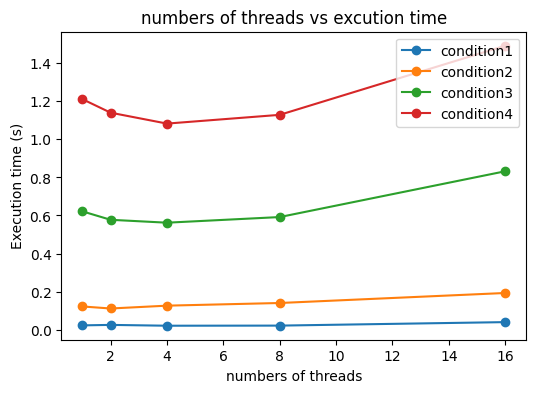

In [7]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize = (6, 4))
for i in range(0, len(total_time_list)):
    plt.plot(core, total_time_list[i], marker = 'o',linestyle ='-', label=(f'condition{i+1}'))
#plt.plot(values2, results2,  label = 'without vectorization', marker = 'o', linestyle ='-')
#plt.title('vectorization vs original')
plt.xlabel('numbers of threads')
plt.ylabel('Execution time (s)')
plt.title(f'numbers of threads vs excution time')
plt.legend()
plt.show()

In [10]:
condition = pd.DataFrame(test_inputs, columns=['program', 'nsteps', 'nmax', 'temp', 'pflag'])
condition.index.name='Condition'
condition

,program,nsteps,nmax,temp,pflag
Condition,,,,,
0,LL,50,10,0.5,0
1,LL,50,100,0.5,0
2,LL,50,1000,0.5,0
3,LL,50,2000,0.5,0


In [7]:
test_inputs = [
    ("LL", 50, 10, 0.5, 0),
    ("LL", 50, 100, 0.5, 0),
    ("LL", 50, 200, 0.5, 0),
    ("LL", 50, 500, 0.5, 0),
]

In [9]:
core = [1,2,4,8,16]
total_time_list = []

for program, nsteps, nmax, temp, pflag in test_inputs:
    time_list = []
    for n in core:
        start = time.time()
        llp.main(program, nsteps, nmax, temp, pflag, n)
        end = time.time()
        time_list.append(end-start)
        print(f"Threads number:{n},running time:{end-start}")
    total_time_list.append(time_list)

LL: Size: 10, Steps: 50, T*: 0.500: Order: 0.388, Time: 0.058284 s
Threads number:1,running time:0.06260895729064941
LL: Size: 10, Steps: 50, T*: 0.500: Order: 0.508, Time: 0.041234 s
Threads number:2,running time:0.04267287254333496
LL: Size: 10, Steps: 50, T*: 0.500: Order: 0.494, Time: 0.050478 s
Threads number:4,running time:0.051514387130737305
LL: Size: 10, Steps: 50, T*: 0.500: Order: 0.607, Time: 0.047145 s
Threads number:8,running time:0.048349618911743164
LL: Size: 10, Steps: 50, T*: 0.500: Order: 0.289, Time: 0.047836 s
Threads number:16,running time:0.04887866973876953
LL: Size: 100, Steps: 50, T*: 0.500: Order: 0.265, Time: 3.726566 s
Threads number:1,running time:3.777463912963867
LL: Size: 100, Steps: 50, T*: 0.500: Order: 0.296, Time: 3.573564 s
Threads number:2,running time:3.627878189086914
LL: Size: 100, Steps: 50, T*: 0.500: Order: 0.274, Time: 4.028166 s
Threads number:4,running time:4.08333945274353
LL: Size: 100, Steps: 50, T*: 0.500: Order: 0.280, Time: 3.687301

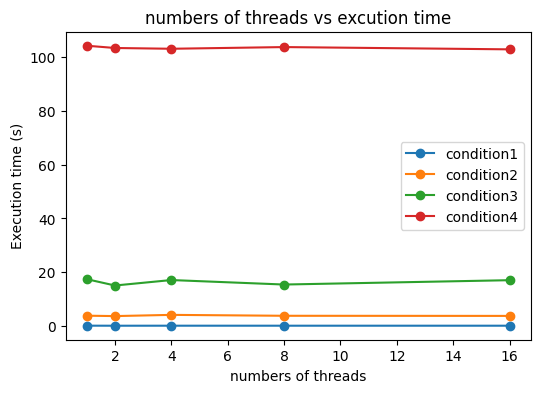

In [10]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize = (6, 4))
for i in range(0, len(total_time_list)):
    plt.plot(core, total_time_list[i], marker = 'o',linestyle ='-', label=(f'condition{i+1}'))
#plt.plot(values2, results2,  label = 'without vectorization', marker = 'o', linestyle ='-')
#plt.title('vectorization vs original')
plt.xlabel('numbers of threads')
plt.ylabel('Execution time (s)')
plt.title(f'numbers of threads vs excution time')
plt.legend()
plt.show()

In [11]:
condition = pd.DataFrame(test_inputs, columns=['program', 'nsteps', 'nmax', 'temp', 'pflag'])
condition.index.name='Condition'
condition

,program,nsteps,nmax,temp,pflag
Condition,,,,,
0,LL,50,10,0.5,0
1,LL,50,100,0.5,0
2,LL,50,200,0.5,0
3,LL,50,500,0.5,0
